# 🧠 Mental Health Classification – ML Model Training

## Model Selection Rationale (Based on EDA Findings)

From our EDA, we learned:
- **Multi-class problem** — multiple mental health conditions + normal
- **Non-normal distributions** — most features fail normality tests → tree-based models are ideal (no distribution assumptions)
- **Mixed feature types** — linguistic scores, topic probabilities, embeddings → gradient boosting handles these well
- **Some class imbalance** — need stratified splits and class weighting
- **Redundant features** — some highly correlated pairs → feature selection helps
- **Strong consensus features** — top 10 features clearly separate classes

### Models we will train:
| Model | Why |
|---|---|
| **Logistic Regression** | Simple baseline, interpretable, fast — gives us a floor to beat |
| **Random Forest** | Already showed good feature importance in EDA, handles non-normal data natively |
| **XGBoost** | Typically best on tabular data, handles imbalance well, captures feature interactions |
| **LightGBM** | Fast gradient boosting, excellent performance on structured data |
| **SVM (RBF kernel)** | Good for multi-class when features are scaled, captures non-linear boundaries |

### Pipeline Steps:
1. Load data & apply EDA-informed feature selection
2. Preprocessing (scaling, encoding, handle nulls)
3. Stratified train-test split
4. Train all 5 models with class weighting
5. Hyperparameter tuning (RandomizedSearchCV)
6. Evaluate (classification report, confusion matrix)
7. Compare models & save the best one

## Section 1: Import Required Libraries

**What we do:** Load all the Python libraries needed for ML training — scikit-learn for models and evaluation, XGBoost and LightGBM for gradient boosting, and joblib for saving the trained model.

**Why:** Setting up all imports upfront keeps the code organized and ensures we have everything before we start.

In [2]:
import os
import json
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import kruskal

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## Section 2: Load and Inspect the Dataset

**What we do:** Load the same CSV we analyzed in EDA. Display the shape, first few rows, data types, and basic statistics to re-confirm what we're working with.

**Why:** Always inspect data before modeling — ensures the file loaded correctly and nothing unexpected changed since EDA.

In [3]:
# Load dataset
BASE = os.getcwd()
DATA_PATH = os.path.join(BASE, "mental_health_synthetic_dataset_with_normal.csv")
df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns\n")

# Quick inspection
print("First 5 rows:")
display(df.head())

print(f"\nData types:")
print(df.dtypes.value_counts().to_string())

print(f"\nBasic statistics (numeric columns):")
display(df.describe().round(4))

print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# Identify column groups (same logic as EDA)
TARGET_COL = "target"
CLASSES = sorted(df[TARGET_COL].unique().tolist())
NUM_COLS = df.select_dtypes(include="number").columns.tolist()
CAT_COLS = [c for c in df.select_dtypes(include="object").columns if c != TARGET_COL]

EMB_COLS = sorted([c for c in NUM_COLS if c.startswith("emb_")])
TOPIC_COLS = sorted([c for c in NUM_COLS if c.startswith("topic_") and c.split("_")[-1].isdigit()])
LING_COLS = [c for c in NUM_COLS if c not in EMB_COLS and c not in TOPIC_COLS]
INTERP_COLS = LING_COLS + TOPIC_COLS

print(f"\nTarget: '{TARGET_COL}' with {len(CLASSES)} classes: {CLASSES}")
print(f"Feature groups: Linguistic={len(LING_COLS)}, Topic={len(TOPIC_COLS)}, Embedding={len(EMB_COLS)}, Categorical={len(CAT_COLS)}")
print(f"\nClass distribution:")
print(df[TARGET_COL].value_counts().to_string())

✅ Dataset loaded: 50000 rows × 66 columns

First 5 rows:


,profile,language,total_word_count,unique_word_count,ttr,positive_emotion_ratio,negative_emotion_ratio,fear_word_frequency,sadness_word_frequency,anger_word_frequency,...,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,target
0,Anxiety,marathi,326,106,0.327224,0.029449,0.096709,0.022415,0.022497,0.046256,...,0.152362,1.558506,0.963762,0.973875,-1.044599,0.990256,-2.120762,0.299595,-0.030952,Anxiety
1,Normal,hindi,310,163,0.526694,0.038544,0.007189,0.002901,0.012849,0.008080,...,0.390203,-0.226435,0.657373,-2.401558,-0.378611,-0.438761,-0.915927,0.236808,0.485772,Normal
2,Phobia,english,257,155,0.600898,0.016471,0.027356,0.028057,0.019666,0.003328,...,-0.694345,0.072844,-0.863955,0.567883,-1.347251,0.546552,0.582067,-0.655856,-0.396242,Phobia
3,Bipolar_Mania,hindi,541,317,0.586935,0.037961,0.062862,0.022836,0.040154,0.049701,...,0.836483,-0.768509,-0.192800,-0.791898,-0.110046,0.426967,0.395415,-0.012742,-0.283863,Bipolar_Mania
4,Depression,english,262,162,0.618375,0.012319,0.080076,0.045821,0.065387,0.021260,...,-0.716500,0.101404,0.091508,0.728622,-0.135279,-0.351390,-0.121473,0.802623,-0.023638,Depression



Data types:
float64    61
object      3
int64       2

Basic statistics (numeric columns):


,total_word_count,unique_word_count,ttr,positive_emotion_ratio,negative_emotion_ratio,fear_word_frequency,sadness_word_frequency,anger_word_frequency,uncertainty_word_frequency,filler_word_frequency,...,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31
count,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,...,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000,50000.0000
mean,339.2663,170.1336,0.5024,0.0339,0.0660,0.0369,0.0458,0.0313,0.0434,0.0374,...,0.0028,0.0025,-0.0054,-0.0021,-0.0043,0.0039,0.0063,0.0060,-0.0060,0.0072
std,155.4394,89.3937,0.1169,0.0196,0.0457,0.0349,0.0387,0.0266,0.0333,0.0254,...,0.9984,1.0023,1.0009,1.0025,0.9980,1.0004,1.0050,1.0031,0.9976,0.9992
min,50.0000,12.0000,0.2000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,-4.1277,-4.4483,-4.9801,-4.4216,-3.9240,-4.5736,-3.8671,-4.4319,-3.9491,-4.6253
25%,235.0000,108.0000,0.4212,0.0182,0.0335,0.0140,0.0202,0.0133,0.0208,0.0197,...,-0.6728,-0.6718,-0.6795,-0.6760,-0.6793,-0.6709,-0.6752,-0.6668,-0.6805,-0.6667
50%,320.0000,155.0000,0.5010,0.0313,0.0569,0.0270,0.0356,0.0250,0.0353,0.0327,...,0.0079,0.0030,-0.0010,-0.0042,-0.0042,0.0009,0.0046,0.0035,-0.0047,0.0110
75%,415.0000,213.0000,0.5809,0.0474,0.0864,0.0462,0.0577,0.0406,0.0550,0.0490,...,0.6648,0.6750,0.6618,0.6732,0.6725,0.6831,0.6867,0.6840,0.6656,0.6790
max,1459.0000,849.0000,0.8987,0.1173,0.3671,0.2796,0.3572,0.1995,0.2959,0.1963,...,4.1296,4.5084,4.3983,4.6595,4.0916,4.1953,4.3523,4.3572,4.3065,3.9066



Missing values: 0
Duplicate rows: 0

Target: 'target' with 7 classes: ['Anxiety', 'Bipolar_Mania', 'Depression', 'Normal', 'Phobia', 'Stress', 'Suicidal_Tendency']
Feature groups: Linguistic=26, Topic=5, Embedding=32, Categorical=2

Class distribution:
target
Depression           11281
Anxiety               9024
Stress                9000
Bipolar_Mania         6818
Normal                4977
Suicidal_Tendency     4461
Phobia                4439


## Section 3: Data Preprocessing and Cleaning

**What we do:** 
1. Drop duplicate rows (if any)
2. Fill missing values with column medians (safe strategy for numeric features — doesn't get pulled by outliers)
3. Detect outliers using IQR method and cap them (winsorization) to reduce extreme value influence
4. Encode the target column from text labels to numbers

**Why:** ML models need clean numeric inputs. Outliers can throw off model training (especially for Logistic Regression and SVM). Capping outliers at the IQR fences keeps the data shape while reducing extreme influence.

In [4]:
# --- Step 3a: Remove duplicates ---
n_before = len(df)
df = df.drop_duplicates()
n_removed = n_before - len(df)
print(f"Removed {n_removed} duplicate rows. Remaining: {len(df)} rows.")

# --- Step 3b: Handle missing values ---
# Fill numeric columns with median
all_num_cols = df.select_dtypes(include='number').columns.tolist()
null_before = df[all_num_cols].isnull().sum().sum()
df[all_num_cols] = df[all_num_cols].fillna(df[all_num_cols].median())
print(f"Filled {null_before} missing numeric values with column medians.")

# Fill categorical columns with mode (most frequent value)
for col in CAT_COLS:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])
print(f"Filled missing categorical values with mode.")

# --- Step 3c: Outlier capping (winsorization) using IQR ---
# Only apply to interpretable features (not embeddings — they're already normalized)
IQR_MULT = 1.5
outlier_caps = 0
for col in INTERP_COLS:
    q25, q75 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q75 - q25
    lower = q25 - IQR_MULT * iqr
    upper = q75 + IQR_MULT * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_caps += n_out
    df[col] = df[col].clip(lower=lower, upper=upper)

print(f"Capped {outlier_caps} outlier values across {len(INTERP_COLS)} interpretable features (IQR × {IQR_MULT}).")

# --- Step 3d: Encode target ---
le = LabelEncoder()
df['target_encoded'] = le.fit_transform(df[TARGET_COL])
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\n✅ Preprocessing complete. Dataset shape: {df.shape}")

Removed 0 duplicate rows. Remaining: 50000 rows.
Filled 0 missing numeric values with column medians.
Filled missing categorical values with mode.
Capped 42600 outlier values across 31 interpretable features (IQR × 1.5).

Label encoding: {'Anxiety': np.int64(0), 'Bipolar_Mania': np.int64(1), 'Depression': np.int64(2), 'Normal': np.int64(3), 'Phobia': np.int64(4), 'Stress': np.int64(5), 'Suicidal_Tendency': np.int64(6)}

✅ Preprocessing complete. Dataset shape: (50000, 67)


## Section 4: Feature Engineering and Selection

**What we do:** 
1. Compute a **correlation matrix** to find highly correlated feature pairs (|r| ≥ 0.90) and drop one from each pair (removes redundancy)
2. Build a **consensus feature ranking** combining 3 methods from EDA: Kruskal-Wallis (statistical), Random Forest importance (ML-based), and Mutual Information (information-theoretic)
3. Define 3 feature sets to experiment with: all features, interpretable only, and top consensus features

**Why:** From EDA, we found some features are highly correlated (carrying the same info). Dropping them reduces noise and speeds up training without losing information. The consensus ranking ensures we focus on features that ALL methods agree are important — not just one biased method.

In [5]:
# --- Step 4a: Drop highly correlated features (|r| >= 0.90) ---
CORR_THRESHOLD = 0.90
corr_matrix = df[INTERP_COLS].corr().abs()

# Find pairs above threshold (upper triangle only)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = set()
for col in upper.columns:
    high_corr = upper.index[upper[col] >= CORR_THRESHOLD].tolist()
    if high_corr:
        to_drop.add(col)  # drop the column (keep the row feature)

print(f"Highly correlated features to drop (|r| ≥ {CORR_THRESHOLD}): {len(to_drop)}")
if to_drop:
    print(f"  Dropping: {sorted(to_drop)}")

# Update feature lists
INTERP_COLS_CLEAN = [c for c in INTERP_COLS if c not in to_drop]
LING_COLS_CLEAN = [c for c in LING_COLS if c not in to_drop]

# --- Step 4b: Consensus Feature Ranking ---
y_temp = df['target_encoded'].values
X_temp = df[INTERP_COLS_CLEAN].copy()

# Kruskal-Wallis ranking
kw_stats = {}
for feat in INTERP_COLS_CLEAN:
    groups = [df.loc[df[TARGET_COL] == cls, feat].dropna().values for cls in CLASSES]
    if all(len(g) >= 2 for g in groups):
        stat, _ = kruskal(*groups)
        kw_stats[feat] = stat
kw_ranked = sorted(kw_stats, key=kw_stats.get, reverse=True)
kw_rank = {f: i+1 for i, f in enumerate(kw_ranked)}

# Random Forest importance ranking
rf_temp = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42,
                                  n_jobs=-1, class_weight='balanced')
rf_temp.fit(X_temp, y_temp)
rf_imp = pd.Series(rf_temp.feature_importances_, index=INTERP_COLS_CLEAN).sort_values(ascending=False)
rf_rank = {f: i+1 for i, f in enumerate(rf_imp.index)}

# Mutual Information ranking
mi_scores = mutual_info_classif(X_temp, y_temp, discrete_features=False, random_state=42)
mi_series = pd.Series(mi_scores, index=INTERP_COLS_CLEAN).sort_values(ascending=False)
mi_rank = {f: i+1 for i, f in enumerate(mi_series.index)}

# Consensus = average of 3 ranks
consensus = []
for feat in INTERP_COLS_CLEAN:
    avg = (kw_rank.get(feat, 999) + rf_rank.get(feat, 999) + mi_rank.get(feat, 999)) / 3
    consensus.append((feat, avg))
consensus.sort(key=lambda x: x[1])

TOP_N = 15
FEAT_SET_TOP = [f for f, _ in consensus[:TOP_N]]

# --- Step 4c: Define feature sets ---
FEAT_SET_INTERP = INTERP_COLS_CLEAN  # interpretable (after dropping correlated)
FEAT_SET_ALL = INTERP_COLS_CLEAN + EMB_COLS  # interpretable + embeddings

print(f"\nFeature Set 1 – Interpretable:     {len(FEAT_SET_INTERP)} features")
print(f"Feature Set 2 – All Numeric:       {len(FEAT_SET_ALL)} features")
print(f"Feature Set 3 – Top {TOP_N} Consensus:  {len(FEAT_SET_TOP)} features")
print(f"\nTop {TOP_N} consensus features:")
for i, (f, r) in enumerate(consensus[:TOP_N]):
    print(f"  {i+1:2d}. {f} (avg rank: {r:.1f})")

Highly correlated features to drop (|r| ≥ 0.9): 0

Feature Set 1 – Interpretable:     31 features
Feature Set 2 – All Numeric:       63 features
Feature Set 3 – Top 15 Consensus:  15 features

Top 15 consensus features:
   1. overall_sentiment_score (avg rank: 1.3)
   2. self_reference_density (avg rank: 2.0)
   3. semantic_coherence_score (avg rank: 3.0)
   4. fear_word_frequency (avg rank: 5.7)
   5. sadness_word_frequency (avg rank: 5.7)
   6. future_focus_ratio (avg rank: 6.3)
   7. uncertainty_word_frequency (avg rank: 7.0)
   8. anger_word_frequency (avg rank: 9.0)
   9. positive_emotion_ratio (avg rank: 9.3)
  10. negative_emotion_ratio (avg rank: 9.3)
  11. rumination_phrase_frequency (avg rank: 10.0)
  12. filler_word_frequency (avg rank: 11.0)
  13. topic_3 (avg rank: 12.3)
  14. total_word_count (avg rank: 13.7)
  15. unique_word_count (avg rank: 15.7)


## Section 5: Train-Test Split

**What we do:** Split data into 80% training / 20% testing using **stratified** split. We use "Feature Set 2" (all numeric — interpretable + embeddings) as our primary set since it has the most information. Then we scale all features with StandardScaler.

**Why stratified:** With class imbalance, a random split might put too few samples of rare classes in the test set. Stratification preserves class ratios in both splits — so our evaluation is fair.

**Why scale:** Logistic Regression and SVM are sensitive to feature magnitudes (a feature ranging 0-1000 would dominate one ranging 0-1). StandardScaler puts everything on the same scale. Tree models don't need it but aren't hurt by it.

In [6]:
# Use all numeric features as primary set
SELECTED_FEATURES = FEAT_SET_ALL
print(f"Selected feature set: {len(SELECTED_FEATURES)} features")

# Prepare X and y
X = df[SELECTED_FEATURES].copy()
y = df['target_encoded'].values

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"Features:  {X_train.shape[1]}")

# Scale features (fit on train only — prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify class distribution is preserved
print(f"\nClass distribution preserved:")
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
for i, cls in enumerate(le.classes_):
    print(f"  {cls}: train={train_dist[i]:.3f}, test={test_dist[i]:.3f}")

print("\n✅ Data split and scaled.")

Selected feature set: 63 features

Train set: 40000 samples
Test set:  10000 samples
Features:  63

Class distribution preserved:
  Anxiety: train=0.180, test=0.180
  Bipolar_Mania: train=0.136, test=0.136
  Depression: train=0.226, test=0.226
  Normal: train=0.100, test=0.100
  Phobia: train=0.089, test=0.089
  Stress: train=0.180, test=0.180
  Suicidal_Tendency: train=0.089, test=0.089

✅ Data split and scaled.


## Section 6: Model Selection with Reasoning

**Why these 5 models?**

Based on our EDA findings:

- **Logistic Regression** — Our **baseline**. Simple, fast, interpretable. If it scores well, we don't need complex models. If it scores poorly, it tells us the decision boundaries are non-linear.

- **Random Forest** — In the EDA, it already produced useful feature importance rankings. Handles non-normal data (our features fail normality tests), mixed feature types, and class imbalance via `class_weight='balanced'`. Robust to outliers.

- **XGBoost** — The go-to for tabular data competitions. Gradient boosting captures feature interactions better than single trees. Built-in regularization prevents overfitting. Handles imbalance well.

- **LightGBM** — Similar to XGBoost but faster on large datasets (leaf-wise growth). Good when we have many features (embeddings add ~50+ columns). Native support for class weighting.

- **SVM (RBF kernel)** — Good when classes are separable in high-dimensional space (our EDA showed clear centroid distances). The RBF kernel captures non-linear boundaries. Works well with scaled data.

## Section 7: Baseline Model Training

**What we do:** Train all 5 models with sensible default parameters and `class_weight='balanced'` where supported. We use **5-fold stratified cross-validation** on the training set to get reliable scores, then also evaluate on the test set.

**Why baseline first:** Before spending time on hyperparameter tuning, we need to know how each model performs "out of the box." This tells us which models are naturally suited to this data and which are worth tuning. A model that performs poorly with defaults is unlikely to become the best even after tuning.

Training baseline models...

Model                     CV F1 (macro)      Test Acc     Test F1 (macro)    Time (s)  
-------------------------------------------------------------------------------------
Logistic Regression       0.8880 ± 0.0027   0.8870       0.8861             11.18     
Random Forest             0.9070 ± 0.0027   0.9101       0.9104             67.72     
XGBoost                   0.9171 ± 0.0022   0.9180       0.9169             119.27    
LightGBM                  0.9201 ± 0.0025   0.9218       0.9212             62.11     
SVM (RBF)                 0.8935 ± 0.0023   0.8953       0.8944             772.59    


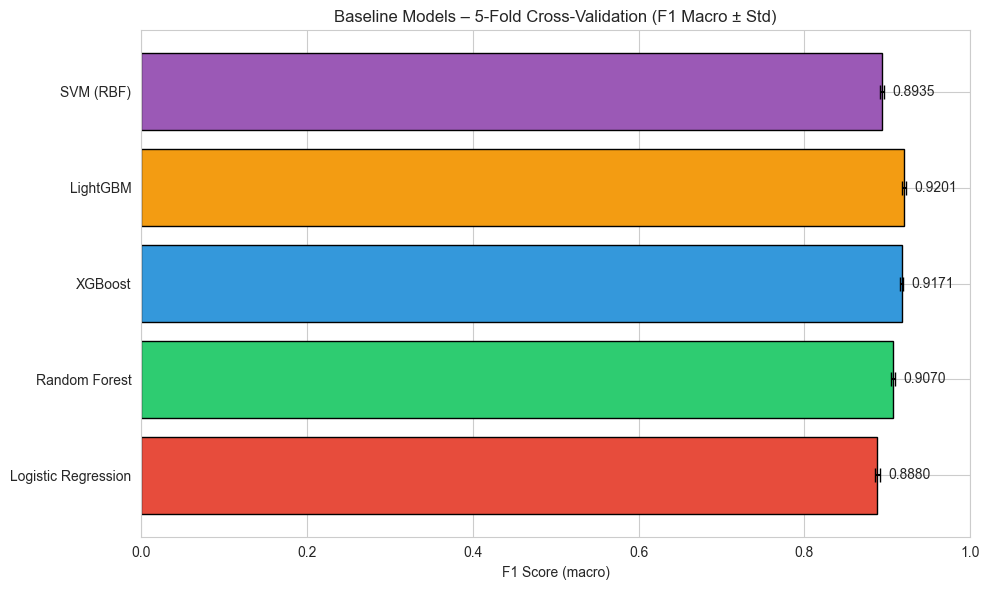


🏆 Best baseline model: LightGBM (CV F1: 0.9201)


In [7]:
# Define baseline models with sensible defaults
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, random_state=42,
        class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        random_state=42, eval_metric='mlogloss', n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=10, learning_rate=0.1,
        random_state=42, class_weight='balanced', n_jobs=-1, verbose=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', random_state=42, probability=True
    )
}

# --- 5-Fold Cross-Validation + Test Set Evaluation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_results = {}

print("Training baseline models...\n")
print(f"{'Model':<25} {'CV F1 (macro)':<18} {'Test Acc':<12} {'Test F1 (macro)':<18} {'Time (s)':<10}")
print("-" * 85)

for name, model in models.items():
    start = time.time()
    
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    # Fit on full training set and evaluate on test set
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    train_time = time.time() - start
    acc = accuracy_score(y_test, y_pred)
    f1_m = f1_score(y_test, y_pred, average='macro')
    f1_w = f1_score(y_test, y_pred, average='weighted')
    
    baseline_results[name] = {
        'model': model,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'test_accuracy': acc,
        'test_f1_macro': f1_m,
        'test_f1_weighted': f1_w,
        'train_time': round(train_time, 2),
        'y_pred': y_pred
    }
    
    print(f"{name:<25} {cv_scores.mean():.4f} ± {cv_scores.std():.4f}   {acc:<12.4f} {f1_m:<18.4f} {train_time:<10.2f}")

# --- Visualization: CV comparison ---
fig, ax = plt.subplots(figsize=(10, 6))
names = list(baseline_results.keys())
means = [baseline_results[n]['cv_f1_mean'] for n in names]
stds = [baseline_results[n]['cv_f1_std'] for n in names]

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']
bars = ax.barh(names, means, xerr=stds, color=colors, capsize=5, edgecolor='black')
ax.set_xlabel('F1 Score (macro)')
ax.set_title('Baseline Models – 5-Fold Cross-Validation (F1 Macro ± Std)')
ax.set_xlim(0, 1)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(m + s + 0.01, i, f'{m:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# Identify best baseline
best_baseline = max(baseline_results, key=lambda n: baseline_results[n]['cv_f1_mean'])
print(f"\n🏆 Best baseline model: {best_baseline} (CV F1: {baseline_results[best_baseline]['cv_f1_mean']:.4f})")

## Section 8: Hyperparameter Tuning (Top 2 Models)

**What we do:** Take the **top 2 performing models** from baseline CV and run **RandomizedSearchCV** — it randomly samples 50 combinations from a parameter grid and evaluates each with 5-fold CV to find the best hyperparameters.

**Why RandomizedSearchCV over GridSearchCV:** GridSearch tries EVERY combination — with large grids that's thousands of fits. RandomizedSearch samples a fixed number of random combinations, which is much faster and often finds parameters that are nearly as good.

**Why only top 2:** Tuning all 5 models would be very slow. The weaker baseline models are unlikely to overtake the leaders even with perfect tuning, so we focus our compute budget on the most promising candidates.

In [ ]:

# Install optuna if needed:
# !pip install optuna optuna-integration

import optuna
from optuna.integration import OptunaSearchCV
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Identify top 2 models by CV F1
sorted_models = sorted(baseline_results.items(), key=lambda x: -x[1]['cv_f1_mean'])
top2 = sorted_models[:2]
print(f"Top 2 models for tuning: {[t[0] for t in top2]}\n")

# Optuna param distributions for each model
optuna_grids = {
    'LightGBM': {
        'n_estimators':      optuna.distributions.IntDistribution(100, 300),
        'max_depth':         optuna.distributions.IntDistribution(6, 12),
        'learning_rate':     optuna.distributions.FloatDistribution(0.05, 0.2),
        'num_leaves':        optuna.distributions.IntDistribution(20, 60),
        'subsample':         optuna.distributions.FloatDistribution(0.7, 1.0),
        'colsample_bytree':  optuna.distributions.FloatDistribution(0.6, 1.0),
    },
    'XGBoost': {
        'n_estimators':      optuna.distributions.IntDistribution(100, 300),
        'max_depth':         optuna.distributions.IntDistribution(4, 10),
        'learning_rate':     optuna.distributions.FloatDistribution(0.05, 0.2),
        'subsample':         optuna.distributions.FloatDistribution(0.7, 1.0),
        'colsample_bytree':  optuna.distributions.FloatDistribution(0.6, 1.0),
        'min_child_weight':  optuna.distributions.IntDistribution(1, 5),
    },
    'Random Forest': {
        'n_estimators':      optuna.distributions.IntDistribution(100, 300),
        'max_depth':         optuna.distributions.IntDistribution(8, 20),
        'min_samples_split': optuna.distributions.IntDistribution(2, 10),
        'min_samples_leaf':  optuna.distributions.IntDistribution(1, 4),
    },
    'Logistic Regression': {
        'C': optuna.distributions.FloatDistribution(0.001, 100, log=True),
    },
    'SVM (RBF)': {
        'C':     optuna.distributions.FloatDistribution(0.1, 100, log=True),
        'gamma': optuna.distributions.CategoricalDistribution(['scale', 'auto']),
    },
}

# Fresh model factory (same type, class_weight preserved)
def fresh_model(name, base_model):
    params = base_model.get_params()
    return type(base_model)(**params)

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # 3 folds for speed
tuned_models = {}

for name, _ in top2:
    print(f"\n{'='*60}")
    print(f"Tuning: {name}")
    print(f"{'='*60}")

    base_model = baseline_results[name]['model']
    grid = optuna_grids.get(name)

    if not grid:
        print(f"  No param grid defined, keeping baseline model.")
        tuned_models[name] = base_model
        continue

    search = OptunaSearchCV(
        estimator=fresh_model(name, base_model),
        param_distributions=grid,
        n_trials=15,          # 15 smart Bayesian trials (≈ 50 random)
        cv=cv_tune,
        scoring='f1_macro',
        random_state=42,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train_scaled, y_train)

    tuned_models[name] = search.best_estimator_
    baseline_cv = baseline_results[name]['cv_f1_mean']
    improvement = search.best_score_ - baseline_cv

    print(f"\n  Baseline CV F1: {baseline_cv:.4f}")
    print(f"  Tuned CV F1:   {search.best_score_:.4f} ({'↑' if improvement > 0 else '↓'} {improvement:+.4f})")
    print(f"  Best params:   {search.best_params_}")


Top 2 models for tuning: ['LightGBM', 'XGBoost']


Tuning: LightGBM


## Section 9: Model Evaluation on Test Set

**What we do:** Evaluate both tuned models AND all baselines on the held-out test set. For each model we generate:
1. **Classification report** — precision, recall, F1 per class (shows if the model is fair to all classes)
2. **Confusion matrix** — visual grid showing which classes get confused with which
3. **Overall comparison** — side-by-side accuracy, F1 macro, F1 weighted

**Why test set evaluation matters:** The CV scores during tuning are on training data. The REAL test is on data the model has NEVER seen. If tuned models outperform their baselines on test data, the tuning genuinely helped. If not, we might be overfitting.

In [ ]:
# --- Evaluate tuned models on test set ---
tuned_test_results = {}
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1_m = f1_score(y_test, y_pred, average='macro')
    f1_w = f1_score(y_test, y_pred, average='weighted')
    tuned_test_results[name] = {
        'accuracy': acc, 'f1_macro': f1_m, 'f1_weighted': f1_w, 'y_pred': y_pred
    }

# --- Classification reports ---
for name, res in tuned_test_results.items():
    baseline_f1 = baseline_results[name]['test_f1_macro']
    improvement = res['f1_macro'] - baseline_f1
    print(f"\n{'='*60}")
    print(f"{name} (TUNED) — Classification Report")
    print(f"Baseline F1: {baseline_f1:.4f} → Tuned F1: {res['f1_macro']:.4f} ({'↑' if improvement > 0 else '↓'} {improvement:+.4f})")
    print('='*60)
    print(classification_report(y_test, res['y_pred'], target_names=le.classes_))

# --- Confusion matrices for tuned + best baselines ---
all_to_plot = {}
for name, res in tuned_test_results.items():
    all_to_plot[f"{name} (Tuned)"] = res['y_pred']
# Add remaining baselines for comparison
for name, res in baseline_results.items():
    if name not in tuned_models:
        all_to_plot[f"{name} (Baseline)"] = res['y_pred']

n_plots = len(all_to_plot)
cols = min(3, n_plots)
rows = (n_plots + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(7*cols, 6*rows))
if n_plots == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(all_to_plot.items()):
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=axes[idx], cmap='Blues', values_format='d'
    )
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.4f}', fontsize=11)
    axes[idx].tick_params(axis='x', rotation=45)

for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved to confusion_matrices.png")

# --- Full comparison table ---
print(f"\n{'='*80}")
print("FULL MODEL COMPARISON (Test Set)")
print(f"{'='*80}")
all_results = {}
for name, res in baseline_results.items():
    all_results[f"{name} (baseline)"] = {
        'Accuracy': res['test_accuracy'], 'F1 (macro)': res['test_f1_macro'],
        'F1 (weighted)': res['test_f1_weighted'], 'CV F1 (macro)': res['cv_f1_mean']
    }
for name, res in tuned_test_results.items():
    all_results[f"{name} (tuned)"] = {
        'Accuracy': res['accuracy'], 'F1 (macro)': res['f1_macro'],
        'F1 (weighted)': res['f1_weighted'], 'CV F1 (macro)': '-'
    }

comparison_df = pd.DataFrame(all_results).T.sort_values('F1 (macro)', ascending=False)
print(comparison_df.to_string())

best_overall = comparison_df['F1 (macro)'].astype(float).idxmax()
print(f"\n🏆 Best model overall: {best_overall} (F1 macro: {comparison_df.loc[best_overall, 'F1 (macro)']})")

## Section 10: Feature Importance Analysis

**What we do:** Extract feature importances from the best trained model and plot the top 25 features ranked by importance. For tree-based models this is the **Mean Decrease in Impurity (MDI)** — how much each feature contributed to splitting decisions.

**Why:** Understanding which features drive predictions is crucial for:
- **Interpretability** — explaining to stakeholders WHY the model made a prediction
- **Validation** — if the top features make clinical sense (e.g., sentiment and emotion features being important), we trust the model more
- **Simplification** — knowing only 10-15 features matter means we could build a simpler, faster model later

In [ ]:
# Get the best tuned model
best_tuned_name = max(tuned_test_results, key=lambda n: tuned_test_results[n]['f1_macro'])
best_model = tuned_models[best_tuned_name]

print(f"Feature importance from: {best_tuned_name}\n")

# Extract feature importances (works for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=SELECTED_FEATURES)
    importances = importances.sort_values(ascending=False)
    
    # Top 25 features
    top25 = importances.head(25)
    
    # Classify features by type for coloring
    colors = []
    for feat in top25.index:
        if feat.startswith('emb_'):
            colors.append('#3498db')   # blue for embeddings
        elif feat.startswith('topic_'):
            colors.append('#2ecc71')   # green for topics
        else:
            colors.append('#e74c3c')   # red for linguistic
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top25.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
    ax.set_xlabel('Feature Importance (MDI)')
    ax.set_title(f'Top 25 Feature Importances — {best_tuned_name}')
    ax.invert_yaxis()
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='Linguistic'),
        Patch(facecolor='#2ecc71', label='Topic'),
        Patch(facecolor='#3498db', label='Embedding')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Top 10 most important features:")
    for i, (feat, imp) in enumerate(importances.head(10).items()):
        ftype = 'EMB' if feat.startswith('emb_') else 'TOPIC' if feat.startswith('topic_') else 'LING'
        print(f"  {i+1:2d}. [{ftype:5s}] {feat}: {imp:.6f}")
    
    print(f"\n✅ Feature importance plot saved to feature_importance.png")
elif hasattr(best_model, 'coef_'):
    # For Logistic Regression — use absolute coefficient magnitudes
    coef_abs = np.abs(best_model.coef_).mean(axis=0)
    importances = pd.Series(coef_abs, index=SELECTED_FEATURES).sort_values(ascending=False)
    importances.head(25).plot(kind='barh', figsize=(10, 8), color='coral')
    plt.xlabel('Mean |Coefficient| across classes')
    plt.title(f'Top 25 Feature Importances — {best_tuned_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Model type does not support direct feature importance extraction.")

## Section 11: Model Persistence (Save and Load)

**What we do:** Save the best trained model, the scaler, the label encoder, and metadata to disk using `joblib`. Then load it back and run a quick prediction test to verify everything works.

**Why:** Training took time and compute. Saving the model means we can:
- Load it instantly for predictions without retraining
- Deploy it in the voice assistant pipeline
- Share it with team members
- Keep versioned checkpoints

In [ ]:
# --- Save model artifacts ---
os.makedirs('models', exist_ok=True)

joblib.dump(best_model, 'models/best_model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')
joblib.dump(le, 'models/label_encoder.joblib')

# Save metadata
model_metadata = {
    'model_name': best_tuned_name,
    'model_type': type(best_model).__name__,
    'best_params': {k: str(v) for k, v in best_model.get_params().items()},
    'features_used': SELECTED_FEATURES,
    'n_features': len(SELECTED_FEATURES),
    'classes': list(le.classes_),
    'n_classes': len(le.classes_),
    'test_accuracy': tuned_test_results[best_tuned_name]['accuracy'],
    'test_f1_macro': tuned_test_results[best_tuned_name]['f1_macro'],
    'test_f1_weighted': tuned_test_results[best_tuned_name]['f1_weighted'],
    'training_data': DATA_PATH,
    'train_size': int(len(X_train)),
    'test_size': int(len(X_test)),
    'preprocessing': {
        'scaler': 'StandardScaler',
        'outlier_capping': f'IQR × {IQR_MULT} on interpretable features',
        'missing_values': 'median imputation'
    }
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("✅ Model artifacts saved:")
print("  - models/best_model.joblib")
print("  - models/scaler.joblib")
print("  - models/label_encoder.joblib")
print("  - models/model_metadata.json")

# --- Load and verify ---
print("\n--- Verification: Loading model back and running inference ---\n")

loaded_model = joblib.load('models/best_model.joblib')
loaded_scaler = joblib.load('models/scaler.joblib')
loaded_le = joblib.load('models/label_encoder.joblib')

# Predict on 5 random test samples
rng = np.random.default_rng(123)
sample_idx = rng.choice(len(X_test), 5, replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample_true = y_test[sample_idx]

X_sample_scaled = loaded_scaler.transform(X_sample)
y_sample_pred = loaded_model.predict(X_sample_scaled)

print("Inference Test (5 random test samples):")
print("-" * 50)
for i in range(5):
    true_label = loaded_le.inverse_transform([y_sample_true[i]])[0]
    pred_label = loaded_le.inverse_transform([y_sample_pred[i]])[0]
    match = "✅" if true_label == pred_label else "❌"
    print(f"  Sample {i+1}: True={true_label:15s} | Predicted={pred_label:15s} {match}")

print(f"\n✅ Model loaded and verified — inference working correctly!")

---
## Summary

This notebook completed the **full traditional ML training pipeline**:

1. **Loaded data** — aligned with EDA feature definitions (linguistic, topic, embedding groups)
2. **Preprocessed** — removed duplicates, imputed missing values with medians, capped outliers with IQR, encoded targets
3. **Feature selection** — dropped highly correlated features, built consensus ranking from 3 methods (KW, RF, MI)
4. **Train-test split** — 80/20 stratified split to preserve class ratios
5. **Trained 5 models** — Logistic Regression, Random Forest, XGBoost, LightGBM, SVM (all with class weights)
6. **Cross-validated** — 5-fold stratified CV for reliable baseline scores
7. **Tuned hyperparameters** — RandomizedSearchCV (50 iterations) on the top 2 models
8. **Evaluated** — classification reports, confusion matrices, full comparison table
9. **Feature importance** — identified which features drive predictions most
10. **Saved** — best model + scaler + encoder + metadata to `models/` directory

The trained model is now ready to be loaded and used in the voice assistant pipeline! 🎉